<a href="https://colab.research.google.com/github/vtk251zhdo/Introduction_to_neural_networks/blob/LAB_2/%D0%9B%D0%90%D0%91%D0%9E%D0%A0%D0%90%D0%A2%D0%9E%D0%A0%D0%9D%D0%90_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Імпорт бібліотек

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

Завдання 1

In [5]:
#Генерація випадкових данних

data = {
    'A': np.random.randint(500, 3000, 100),
    'B': np.random.randint(0, 300, 100),
    'C': np.random.randint(50, 500, 100),
    'D': np.random.randint(1000, 2500, 100),
    'E': np.random.randint(10, 200, 100),
    'F': np.random.randint(0, 100, 100)
}

df = pd.DataFrame(data)
df.head()

,A,B,C,D,E,F
0,2992,268,208,1146,155,63
1,965,213,405,1841,181,83
2,864,142,156,2328,47,12
3,631,139,94,1258,87,30
4,933,59,143,1052,38,13


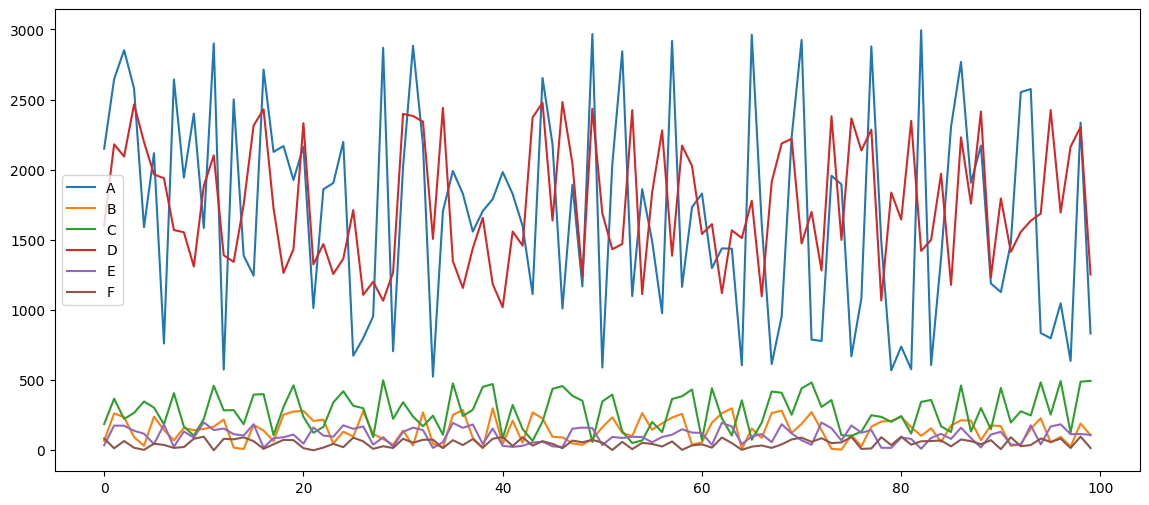

In [4]:
#Графік

plt.figure(figsize=(14,6))

for col in df.columns:
    plt.plot(df[col], label=col)

plt.legend()
plt.show()

Завдання 2

In [6]:
#Нормалізація через MinMaxScaler

scaler = MinMaxScaler()

normalized_data = scaler.fit_transform(df)

normalized_df = pd.DataFrame(
    normalized_data,
    columns=df.columns
)

normalized_df.head()

,A,B,C,D,E,F
0,1.000000,0.898990,0.343249,0.097627,0.777174,0.639175
1,0.179352,0.713805,0.794050,0.568814,0.918478,0.845361
2,0.138462,0.474747,0.224256,0.898983,0.190217,0.113402
3,0.044130,0.464646,0.082380,0.173559,0.407609,0.298969
4,0.166397,0.195286,0.194508,0.033898,0.141304,0.123711


Відображення графіку

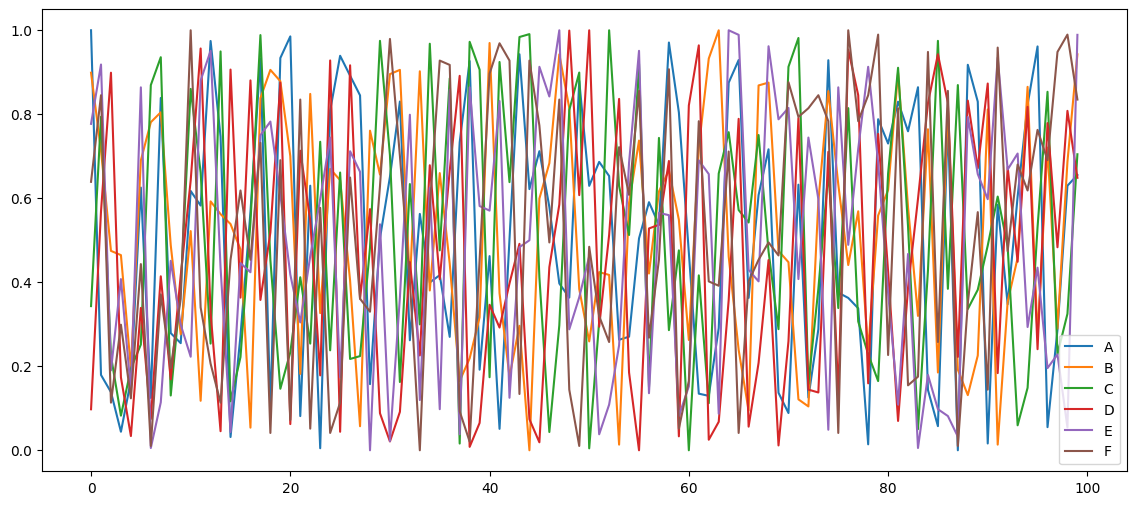

In [7]:
#Графік

plt.figure(figsize=(14,6))

for col in normalized_df.columns:
    plt.plot(normalized_df[col], label=col)

plt.legend()
plt.show()

Завдання 3

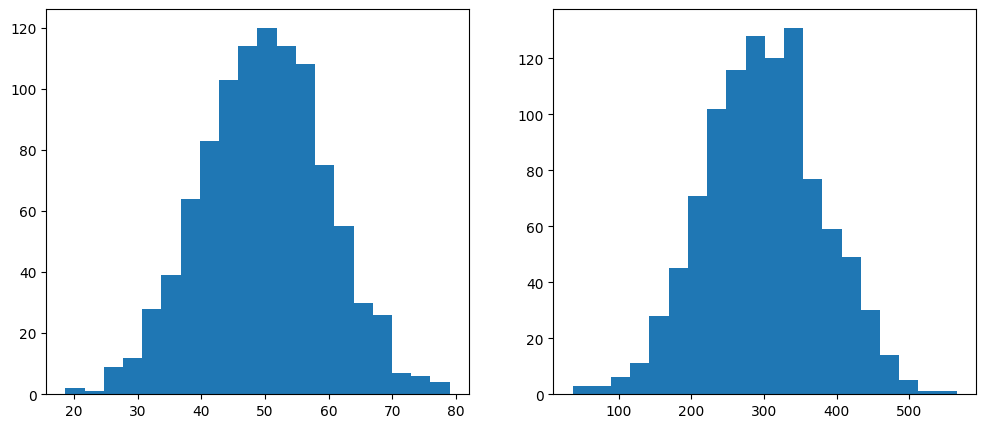

In [8]:
#2 розподіли з різними значеннями проміжку за допомогою np.random.normal.

dist1 = np.random.normal(loc=50, scale=10, size=1000)
dist2 = np.random.normal(loc=300, scale=80, size=1000)

#Гістограми

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(dist1, bins=20)

plt.subplot(1,2,2)
plt.hist(dist2, bins=20)

plt.show()

Завдання 4

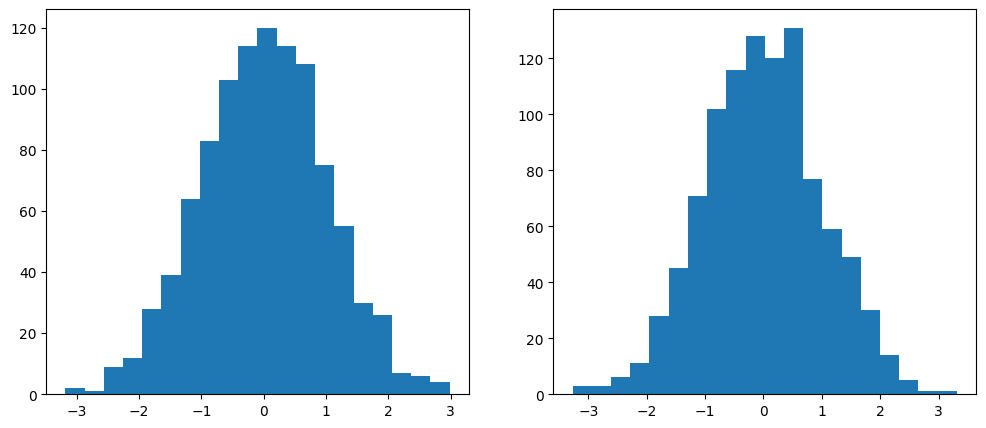

In [9]:
#Стандартизація через StandardScaler

std_scaler = StandardScaler()

dist1_scaled = std_scaler.fit_transform(dist1.reshape(-1,1))
dist2_scaled = std_scaler.fit_transform(dist2.reshape(-1,1))

#Гістограми

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(dist1_scaled, bins=20)

plt.subplot(1,2,2)
plt.hist(dist2_scaled, bins=20)

plt.show()

Завдання 5

In [14]:
df = pd.read_csv('alarms_no_scalse.csv')
df.head()

X = df.drop('sound', axis=1)
y = df['alarm']

#Test train

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

#Побудова моделі

model = Sequential([
    Dense(16, activation='relu', input_shape=(X.shape[1],)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

#Компіляція

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

#Навчання

model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=16
)

#Тестування

loss, acc = model.evaluate(X_test, y_test)

print("Accuracy:", acc)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.0000e+00 - loss: 159.9910
Epoch 2/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0000e+00 - loss: 32.2224
Epoch 3/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0000e+00 - loss: 18.0685
Epoch 4/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0000e+00 - loss: 31.8087
Epoch 5/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0000e+00 - loss: 32.4641
Epoch 6/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0000e+00 - loss: 28.2089
Epoch 7/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0000e+00 - loss: 27.4502
Epoch 8/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0000e+00 - loss: 19.5107
Epoch 9/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0000e+00 - loss: 23.5309
Epoch 10/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0000e+00 - loss: 17.7477
Epoch 11/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0000e+00 - loss: 19.6125
Epoch 1

Завдання 6

In [18]:
#Нормалізація

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42
)

#Навчання

model_scaled = Sequential([
    Dense(16, activation='relu', input_shape=(X.shape[1],)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_scaled.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_scaled.fit(
    X_train, y_train,
    epochs=20,
    batch_size=16
)

#Тестування

loss, acc = model_scaled.evaluate(X_test, y_test)

print("Scaled Accuracy:", acc)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.0000e+00 - loss: 0.6111
Epoch 2/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0000e+00 - loss: 0.5548
Epoch 3/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0000e+00 - loss: 0.5458
Epoch 4/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0000e+00 - loss: 0.5424
Epoch 5/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0000e+00 - loss: 0.5402
Epoch 6/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0000e+00 - loss: 0.5388
Epoch 7/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0000e+00 - loss: 0.5379
Epoch 8/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0000e+00 - loss: 0.5374
Epoch 9/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0000e+00 - loss: 0.5370
Epoch 10/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0000e+00 - loss: 0.5367
Epoch 11/20
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0000e+00 - loss: 0.5365
Epoch 12/20
150/150